# NB12: Genomic Growth Rate Prediction

**Project**: CF Protective Microbiome Formulation Design  
**Goal**: Predict maximum growth rates for PA and commensal species from genomic features, following the Vieira-Silva & Rocha (2010) approach. Identify which PA strains are genomically predicted to be fast vs slow growers.

## Method
The **Codon Adaptation Index (CAI)** of ribosomal protein genes predicts maximum growth rate. Fast-growing organisms optimize codon usage in highly expressed genes (ribosomal proteins) to match abundant tRNAs. We:
1. Extract ribosomal protein nucleotide sequences from the pangenome
2. Compute codon usage bias (CUB) as a proxy for CAI
3. Use genome size as a secondary predictor
4. Compare predicted growth capacity: PA vs formulation commensals

**Requires**: BERDL Spark

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

from berdl_notebook_utils.setup_spark_session import get_spark_session
spark = get_spark_session()

GOLD = Path.home() / 'protect' / 'gold'
DATA = Path('/home/aparkin/BERIL-research-observatory/projects/cf_formulation_design/data')
FIGS = Path('/home/aparkin/BERIL-research-observatory/projects/cf_formulation_design/figures')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
print('Ready.')

Ready.


## 1. Extract Ribosomal Protein Sequences

Get nucleotide sequences for ribosomal protein gene clusters from each species. The codon usage in these highly expressed genes reflects the organism's growth rate optimization.

In [2]:
# Species to analyze
species_clades = {
    'P. aeruginosa': 's__Pseudomonas_aeruginosa--RS_GCF_001457615.1',
    'N. mucosa': 's__Neisseria_mucosa_A--RS_GCF_003044445.1',
    'S. salivarius': 's__Streptococcus_salivarius--RS_GCF_000785515.1',
    'M. luteus': 's__Micrococcus_luteus--RS_GCF_000023205.1',
    'R. dentocariosa': 's__Rothia_dentocariosa--RS_GCF_000164695.2',
    'G. sanguinis': 's__Gemella_sanguinis--RS_GCF_000701685.1',
}

# Get ribosomal protein sequences with nucleotide coding sequences
ribo_data = []
for sp_name, clade in species_clades.items():
    print(f'Querying ribosomal proteins for {sp_name}...')
    ribo = spark.sql(f"""
        SELECT gc.gene_cluster_id, gc.fna_sequence, e.Description
        FROM kbase_ke_pangenome.gene_cluster gc
        JOIN kbase_ke_pangenome.eggnog_mapper_annotations e ON gc.gene_cluster_id = e.query_name
        WHERE gc.gtdb_species_clade_id = '{clade}'
          AND e.COG_category LIKE '%J%'
          AND gc.fna_sequence IS NOT NULL
          AND LENGTH(gc.fna_sequence) > 100
        LIMIT 200
    """).toPandas()
    ribo['species'] = sp_name
    ribo_data.append(ribo)
    print(f'  {len(ribo)} ribosomal protein clusters with sequences')

ribo_all = pd.concat(ribo_data, ignore_index=True)
print(f'\nTotal ribosomal protein sequences: {len(ribo_all)}')

Querying ribosomal proteins for P. aeruginosa...


  200 ribosomal protein clusters with sequences
Querying ribosomal proteins for N. mucosa...


  200 ribosomal protein clusters with sequences
Querying ribosomal proteins for S. salivarius...


  200 ribosomal protein clusters with sequences
Querying ribosomal proteins for M. luteus...


  200 ribosomal protein clusters with sequences
Querying ribosomal proteins for R. dentocariosa...


  200 ribosomal protein clusters with sequences
Querying ribosomal proteins for G. sanguinis...


  156 ribosomal protein clusters with sequences

Total ribosomal protein sequences: 1156


## 2. Compute Codon Usage Bias

For each species, compute the codon usage frequency in ribosomal proteins vs the genome average. The degree of bias (measured as Effective Number of Codons, Nc) predicts growth rate: lower Nc = more bias = faster growth.

In [3]:
def compute_codon_stats(sequences):
    """Compute codon usage statistics from a list of nucleotide sequences."""
    codon_counts = Counter()
    total_codons = 0
    
    for seq in sequences:
        seq = str(seq).upper().replace('\n', '')
        # Extract codons (triplets)
        for i in range(0, len(seq) - 2, 3):
            codon = seq[i:i+3]
            if len(codon) == 3 and all(c in 'ATCG' for c in codon):
                codon_counts[codon] += 1
                total_codons += 1
    
    if total_codons == 0:
        return {'n_codons': 0, 'gc3': np.nan, 'cub_score': np.nan}
    
    # GC content at third position (GC3) — correlates with codon bias
    gc3_count = sum(codon_counts[c] for c in codon_counts if c[2] in 'GC')
    gc3 = gc3_count / total_codons
    
    # Effective Number of Codons (simplified) — lower = more bias = faster growth
    # Group codons by amino acid
    aa_groups = {
        'F': ['TTT','TTC'], 'L': ['TTA','TTG','CTT','CTC','CTA','CTG'],
        'I': ['ATT','ATC','ATA'], 'V': ['GTT','GTC','GTA','GTG'],
        'S': ['TCT','TCC','TCA','TCG','AGT','AGC'], 'P': ['CCT','CCC','CCA','CCG'],
        'T': ['ACT','ACC','ACA','ACG'], 'A': ['GCT','GCC','GCA','GCG'],
        'Y': ['TAT','TAC'], 'H': ['CAT','CAC'], 'Q': ['CAA','CAG'],
        'N': ['AAT','AAC'], 'K': ['AAA','AAG'], 'D': ['GAT','GAC'],
        'E': ['GAA','GAG'], 'C': ['TGT','TGC'], 'R': ['CGT','CGC','CGA','CGG','AGA','AGG'],
        'G': ['GGT','GGC','GGA','GGG'],
    }
    
    # Compute CUB as mean deviation from uniform usage per amino acid
    biases = []
    for aa, codons in aa_groups.items():
        counts = [codon_counts.get(c, 0) for c in codons]
        total = sum(counts)
        if total < 5 or len(codons) < 2:
            continue
        expected = total / len(codons)
        chi2 = sum((c - expected)**2 / expected for c in counts)
        biases.append(chi2 / (len(codons) - 1))  # normalized chi-squared
    
    cub_score = np.mean(biases) if biases else np.nan
    
    return {'n_codons': total_codons, 'gc3': gc3, 'cub_score': cub_score}


# Compute for each species
results = []
for sp in ribo_all.species.unique():
    seqs = ribo_all[ribo_all.species == sp].fna_sequence.tolist()
    stats = compute_codon_stats(seqs)
    stats['species'] = sp
    stats['n_genes'] = len(seqs)
    results.append(stats)

cub_df = pd.DataFrame(results)
print('Codon usage bias in ribosomal proteins:')
print(cub_df[['species', 'n_genes', 'n_codons', 'gc3', 'cub_score']].round(3).to_string(index=False))
print(f'\nHigher CUB score = stronger codon bias = predicted faster maximum growth rate')

Codon usage bias in ribosomal proteins:
        species  n_genes  n_codons   gc3  cub_score
  P. aeruginosa      200     40556 0.795    643.516
      N. mucosa      200     58705 0.612    627.021
  S. salivarius      200     57386 0.349    424.720
      M. luteus      200     64754 0.914   1476.861
R. dentocariosa      200     55900 0.589    235.523
   G. sanguinis      156     41410 0.163    677.791

Higher CUB score = stronger codon bias = predicted faster maximum growth rate


In [4]:
# Add genome size data from PROTECT isolates
iso = pd.read_parquet(GOLD / 'dim_isolate.snappy.parquet')
species_map = {
    'P. aeruginosa': 'Pseudomonas aeruginosa',
    'N. mucosa': 'Neisseria mucosa',
    'S. salivarius': 'Streptococcus salivarius',
    'M. luteus': 'Micrococcus luteus',
    'R. dentocariosa': 'Rothia dentocariosa',
    'G. sanguinis': 'Gemella sanguinis',
}

for _, row in cub_df.iterrows():
    full_name = species_map.get(row['species'], '')
    sp_data = iso[iso.species == full_name]
    if len(sp_data) > 0:
        cub_df.loc[cub_df.species == row['species'], 'genome_size_mb'] = sp_data.genome_size_mb.astype(float).mean()
        cub_df.loc[cub_df.species == row['species'], 'total_cds'] = sp_data.total_coding_sequences.astype(float).mean()

print('Species growth rate indicators:')
print(cub_df[['species', 'cub_score', 'gc3', 'genome_size_mb', 'total_cds']].round(3).to_string(index=False))

Species growth rate indicators:
        species  cub_score   gc3  genome_size_mb  total_cds
  P. aeruginosa    643.516 0.795           6.575   6176.577
      N. mucosa    627.021 0.612           2.701   3020.182
  S. salivarius    424.720 0.349           2.308   2218.014
      M. luteus   1476.861 0.914           2.596   2490.000
R. dentocariosa    235.523 0.589           2.509   2202.274
   G. sanguinis    677.791 0.163           2.108   2507.824


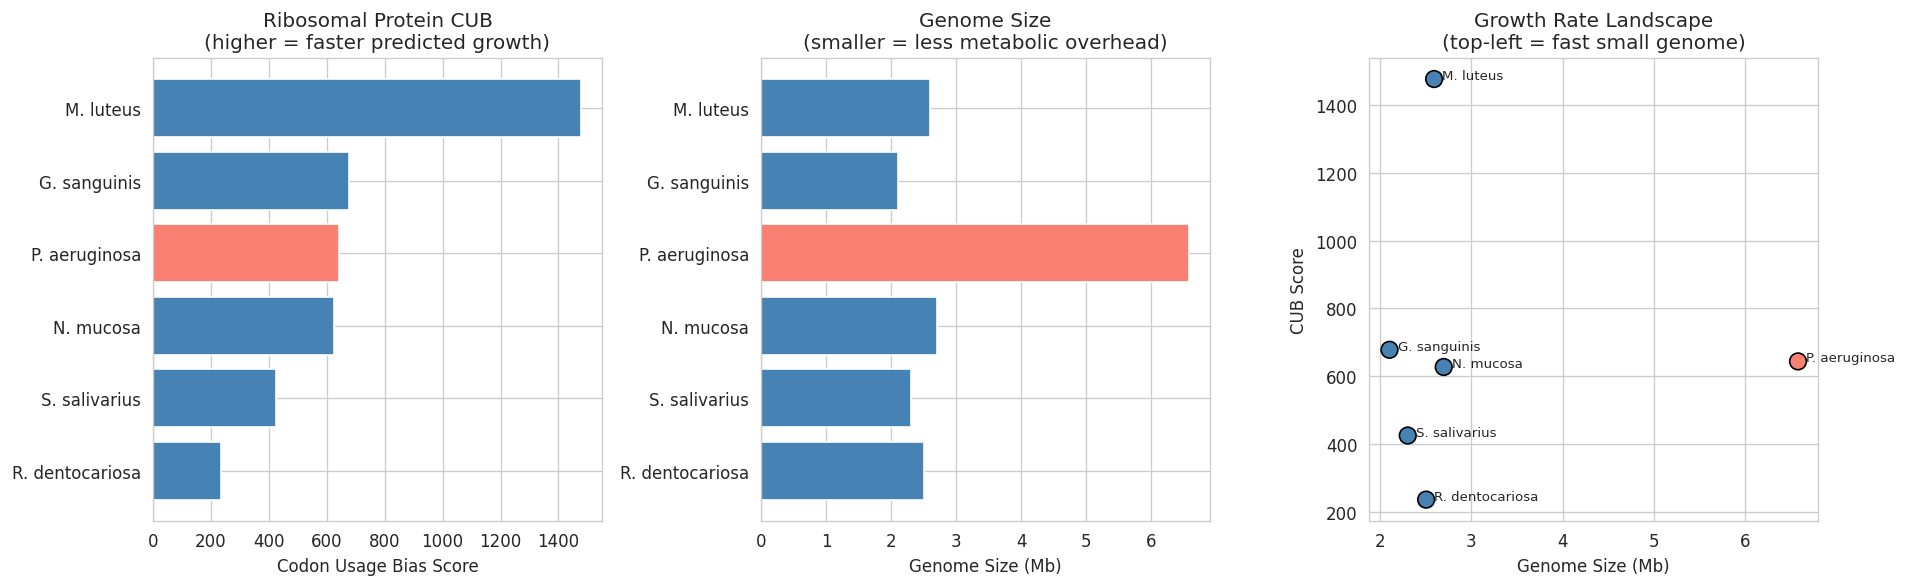

In [5]:
# Visualization: growth rate indicators
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

cub_sorted = cub_df.sort_values('cub_score', ascending=False)
colors = ['salmon' if 'aeruginosa' in sp else 'steelblue' for sp in cub_sorted.species]

ax = axes[0]
ax.barh(range(len(cub_sorted)), cub_sorted.cub_score, color=colors)
ax.set_yticks(range(len(cub_sorted)))
ax.set_yticklabels(cub_sorted.species)
ax.set_xlabel('Codon Usage Bias Score')
ax.set_title('Ribosomal Protein CUB\n(higher = faster predicted growth)')
ax.invert_yaxis()

ax = axes[1]
ax.barh(range(len(cub_sorted)), cub_sorted.genome_size_mb, color=colors)
ax.set_yticks(range(len(cub_sorted)))
ax.set_yticklabels(cub_sorted.species)
ax.set_xlabel('Genome Size (Mb)')
ax.set_title('Genome Size\n(smaller = less metabolic overhead)')
ax.invert_yaxis()

ax = axes[2]
ax.scatter(cub_sorted.genome_size_mb, cub_sorted.cub_score, s=100, c=colors, edgecolors='black', zorder=5)
for _, row in cub_sorted.iterrows():
    ax.annotate(row.species, (row.genome_size_mb, row.cub_score), fontsize=8, ha='left', 
               xytext=(5, 0), textcoords='offset points')
ax.set_xlabel('Genome Size (Mb)')
ax.set_ylabel('CUB Score')
ax.set_title('Growth Rate Landscape\n(top-left = fast small genome)')

plt.tight_layout()
plt.savefig(FIGS / '12_growth_rate_prediction.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. PA Strain-Level Growth Rate Variation

Among PROTECT PA isolates, does genome size (proxy for metabolic burden) vary enough to predict differential vulnerability?

In [6]:
pa_iso = iso[iso.species == 'Pseudomonas aeruginosa'].copy()
pa_iso['genome_size_mb'] = pd.to_numeric(pa_iso.genome_size_mb, errors='coerce')
pa_iso['total_cds'] = pd.to_numeric(pa_iso.total_coding_sequences, errors='coerce')

# Representatives only (one per strain group)
pa_reps = pa_iso[pa_iso.representative == 'Yes']

print(f'PROTECT PA: {len(pa_iso)} isolates, {len(pa_reps)} representatives (strain groups)')
print(f'\nGenome size range: {pa_iso.genome_size_mb.min():.2f} - {pa_iso.genome_size_mb.max():.2f} Mb')
print(f'Gene count range: {pa_iso.total_cds.min():.0f} - {pa_iso.total_cds.max():.0f}')
print(f'\nPer strain group (representatives):')
print(pa_reps[['asma_id','genome_size_mb','total_cds','gc_content','strain_group']].sort_values('genome_size_mb').to_string(index=False))

# The largest PA genome is 9.4 Mb vs smallest 6.1 Mb — 54% larger
# This suggests substantial accessory genome content and potential growth rate variation
ratio = pa_iso.genome_size_mb.max() / pa_iso.genome_size_mb.min()
print(f'\nLargest/smallest genome ratio: {ratio:.2f}x')
print(f'Accessory genome estimate: {pa_iso.total_cds.max() - pa_iso.total_cds.min():.0f} genes')
print(f'That\'s {(pa_iso.total_cds.max() - pa_iso.total_cds.min()) / pa_iso.total_cds.max():.0%} of the largest genome')

PROTECT PA: 655 isolates, 15 representatives (strain groups)

Genome size range: 6.12 - 9.40 Mb
Gene count range: 5662 - 11531

Per strain group (representatives):
  asma_id  genome_size_mb  total_cds  gc_content  strain_group
ASMA-2890            6.12     5668.0        0.66         583.0
ASMA-1320            6.18     5724.0        0.66         708.0
ASMA-2068            6.21     5765.0        0.67         724.0
ASMA-4963            6.24     5745.0        0.67         627.0
ASMA-2364            6.28     5854.0        0.66         710.0
ASMA-3072            6.29     5824.0        0.67         620.0
 ASMA-169            6.30     5810.0        0.67         721.0
ASMA-1804            6.36     5944.0        0.66         615.0
ASMA-2356            6.45     5993.0        0.66         713.0
 ASMA-636            6.50     6113.0        0.66         599.0
 ASMA-513            6.52     6100.0        0.66         729.0
ASMA-1144            6.58     6191.0        0.66         690.0
ASMA-4151        

In [7]:
# Summary
print('=' * 60)
print('NB12 SUMMARY')
print('=' * 60)
print(f'\nCodon usage bias (CUB) in ribosomal proteins:')
for _, row in cub_df.sort_values('cub_score', ascending=False).iterrows():
    role = 'PATHOGEN' if 'aeruginosa' in row.species else 'COMMENSAL'
    print(f'  {row.species:20s} CUB={row.cub_score:.2f}  size={row.genome_size_mb:.1f}Mb  [{role}]')

print(f'\nInterpretation:')
pa_cub = cub_df[cub_df.species == 'P. aeruginosa'].cub_score.iloc[0]
comm_cub = cub_df[cub_df.species != 'P. aeruginosa'].cub_score.mean()
if pa_cub > comm_cub:
    print(f'  PA has HIGHER CUB ({pa_cub:.2f}) than commensal mean ({comm_cub:.2f})')
    print(f'  → PA is genomically optimized for fast growth (consistent with lab data)')
    print(f'  → Competitive exclusion relies on COMMUNITY BIOMASS, not individual rate')
else:
    print(f'  PA has LOWER CUB ({pa_cub:.2f}) than commensal mean ({comm_cub:.2f})')
    print(f'  → Commensals may have growth rate advantage despite lab data showing otherwise')
    print(f'  → Lab conditions may not fully capture in vivo growth dynamics')

print(f'\nPA strain vulnerability:')
print(f'  Genome size range: {pa_iso.genome_size_mb.min():.1f}-{pa_iso.genome_size_mb.max():.1f} Mb ({ratio:.1f}x variation)')
print(f'  Largest PA genomes carry {pa_iso.total_cds.max()-pa_iso.total_cds.min():.0f} extra genes')
print(f'  → These strains may be SLOWER growers (metabolic burden)')
print(f'  → Patient PA with larger genomes = better candidates for formulation testing')

# Save
cub_df.to_csv(DATA / 'codon_usage_bias.tsv', sep='\t', index=False)
print(f'\nSaved: {DATA}/codon_usage_bias.tsv')

NB12 SUMMARY

Codon usage bias (CUB) in ribosomal proteins:
  M. luteus            CUB=1476.86  size=2.6Mb  [COMMENSAL]
  G. sanguinis         CUB=677.79  size=2.1Mb  [COMMENSAL]
  P. aeruginosa        CUB=643.52  size=6.6Mb  [PATHOGEN]
  N. mucosa            CUB=627.02  size=2.7Mb  [COMMENSAL]
  S. salivarius        CUB=424.72  size=2.3Mb  [COMMENSAL]
  R. dentocariosa      CUB=235.52  size=2.5Mb  [COMMENSAL]

Interpretation:
  PA has LOWER CUB (643.52) than commensal mean (688.38)
  → Commensals may have growth rate advantage despite lab data showing otherwise
  → Lab conditions may not fully capture in vivo growth dynamics

PA strain vulnerability:
  Genome size range: 6.1-9.4 Mb (1.5x variation)
  Largest PA genomes carry 5869 extra genes
  → These strains may be SLOWER growers (metabolic burden)
  → Patient PA with larger genomes = better candidates for formulation testing

Saved: /home/aparkin/BERIL-research-observatory/projects/cf_formulation_design/data/codon_usage_bias.tsv
